# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [1]:
from astropy import units as u

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [9]:
speed = 60 * u.kilometer / u.hour
speed_mps = speed.to(u.meter / u.second)
print(f"{speed_mps:.2f}")

16.67 m / s


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [11]:
#A Julian Date (JD) is the count of days and fractions of days since noon Universal Time (UT) on January 1, 4713 BC. It's used by astronomers to calculate the intervals between events.

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [13]:
#They are different in how they define leap years. The Julian calendar is behind the Gregorian calendar by a couple days because it is less accurate in defining a solar year than the Gregorian calendar is.

From the astropy module `time` import `Time` in the cell below.

In [15]:
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [25]:
Current_Time = Time.now().jd
Current_Time

2460735.3232768676

Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [27]:
time = Time("1969-07-02 20:17:00")

time.jd

2440405.345138889

What historically happened at this date and time?

In [29]:
#The Soviet Union's first rocket to the moon, the N1, fails

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [31]:
from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [51]:
ra = 15 * u.degree
dec = (-20) * u.degree
frame = "icrs"

observation_time_UTC = Time.now()
pst_offset = (-8) * u.hour
observation_time_PST = observation_time_UTC + pst_offset

object = SkyCoord(ra=ra, dec=dec, frame=frame)
print(object)

print(observation_time_UTC)
print(observation_time_PST)

<SkyCoord (ICRS): (ra, dec) in deg
    (15., -20.)>
2025-02-28 20:07:22.941399
2025-02-28 12:07:22.941399


Convert the object's coordinates from ICSRS to **Galactic**.

In [39]:
object_galactic = object.transform_to(Galactic())

object_galactic

<SkyCoord (Galactic): (l, b) in deg
    (138.76123783, -82.60718782)>

Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [61]:
campbell_hall = EarthLocation(lat = 37.872979999999998 * u.deg, lon = (-122.25705000000001) * u.deg, height = 54.864 * u.meter)

object_altaz = object.transform_to(AltAz(obstime = observation_time_PST, location = campbell_hall))
print(object_altaz)

<SkyCoord (AltAz: obstime=2025-02-28 12:07:22.941399, location=(-2690550.20955043, -4263101.56369994, 3894358.17382045) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    (54.15502923, -63.2238844)>


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [57]:
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [58]:
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [59]:
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [60]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [67]:
with fits.open(image_file) as hdul:
    hdul.info() #Displaying stuff in imported file
    data = hdul[0].data #Getting primary data
    header = hdul[0].header #Getting header information

Filename: /Users/caitlintran/.astropy/cache/download/url/ff6e0b93871033c68022ca026a956d87/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [71]:
#data array should contain pixel intensity value so taking max of the data array gets the highest insensity value (brightest pixel)
np.max(data)

22918

With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [73]:
np.min(data)

3759

## Tables
From the astropy module `astropy.table` import `Table`.

In [75]:
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [97]:
t = Table()
t["Name"] = ["Alnitak", "Alnilam", "Mintaka"]
t["Magnitude"] = [1.70, 1.69, 2.23]
t["Spectral Type"] = ["O9.5 Iab", "B0 Ia", "O9.5 II"]

t

Name,Magnitude,Spectral Type
str7,float64,str8
Alnitak,1.7,O9.5 Iab
Alnilam,1.69,B0 Ia
Mintaka,2.23,O9.5 II


Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [99]:
t.write("orionsbelt.fits", format="fits")

Read and print the table in the cell below from the `.fits` file you made.

In [110]:
with fits.open("orionsbelt.fits") as hdul:
    hdul.info() #Displaying stuff in imported file
    data = hdul[1].data #Getting primary data
    header = hdul[0].header #Getting header information

print(data)

Filename: orionsbelt.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     14   3R x 3C   [7A, D, 8A]   
[('Alnitak', 1.7 , 'O9.5 Iab') ('Alnilam', 1.69, 'B0 Ia')
 ('Mintaka', 2.23, 'O9.5 II')]


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [112]:
#A graph in astronomy that shows the relation between a star's luminosity and surface temperature (spectral type). It shows the main sequence of stars.

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [114]:
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [129]:
cluster_data = pd.read_csv("cluster_data.tsv", skiprows = 44, sep = ";", header = None, index_col = 0, names = ["HIP", "Vmag", "Plx", "B-V", "SpType"], skipfooter = 1, engine = "python")
cluster_data

,Vmag,Plx,B-V,SpType
HIP,,,,
10,8.59,10.76,0.489,F6V
11,7.34,4.29,0.081,A2
12,8.43,4.06,1.484,K4III
13,8.80,3.49,1.128,K0III
14,7.25,5.11,1.200,K0
...,...,...,...,...
118318,6.99,1.92,1.595,K2
118319,8.23,10.63,0.639,G2V
118320,7.59,5.00,0.999,K0


Display the first few rows of the data.

In [131]:
print(cluster_data.head(3))

      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [135]:
df_clean = cluster_data.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

/var/folders/yr/z3bmf_254gs6t4r3xpst1g3r0000gn/T/ipykernel_8666/2847145003.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = cluster_data.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)


Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [137]:
df_clean.dropna()

,Vmag,Plx,B-V,SpType
HIP,,,,
10,8.59,10.76,0.489,F6V
11,7.34,4.29,0.081,A2
12,8.43,4.06,1.484,K4III
13,8.80,3.49,1.128,K0III
14,7.25,5.11,1.200,K0
...,...,...,...,...
118318,6.99,1.92,1.595,K2
118319,8.23,10.63,0.639,G2V
118320,7.59,5.00,0.999,K0


Run the cell below. We are converting the datatypes in the columns to floats.

In [139]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
print(df_clean.describe())

                Vmag            Plx            B-V
count  118208.000000  117946.000000  116928.000000
mean        8.373183       7.215046       0.706391
std         1.312023      11.286330       0.489828
min        -1.440000     -54.950000      -0.400000
25%         7.640000       2.510000       0.347000
50%         8.440000       4.610000       0.612000
75%         9.150000       8.410000       1.078000
max        14.080000     772.330000       5.460000


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [166]:
Absolute_Magnitude = df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Describe what the cell above is doing. 

In [144]:
#The cell above takes the cleaned dataframe and replaces the values from the Vmag column with the absolute magnitude of the respective star. 

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [148]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].fillna('').str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B5' 'B9' 'M0' 'F8'
 'M1' 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2'
 'A5' 'M4' 'A7' 'O8' 'F1' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'K8'
 'M7' 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'O5' 'K6' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [150]:
# O represents the hottest stars; M reprsents the coolest stars.

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [164]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean = df_clean.dropna(subset=['SpType2'])
Spectral_Type = df_clean.loc[:, 'SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]] * 10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [162]:
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

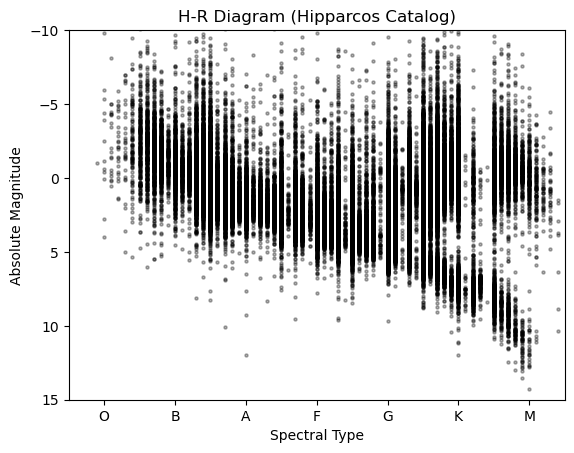

In [184]:
plt.scatter(Spectral_Type, Absolute_Magnitude, s = 5, alpha = 0.3, c = "k")
plt.xlim(0, 70)
plt.ylim(15, -10)

xticklabels = ["O", "B", "A", "F", "G", "K", "M"]
xticks = range(5, 75, 10)

plt.xticks(xticks, xticklabels)

plt.xlabel("Spectral Type")
plt.ylabel("Absolute Magnitude")
plt.title("H-R Diagram (Hipparcos Catalog)")
plt.show()

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

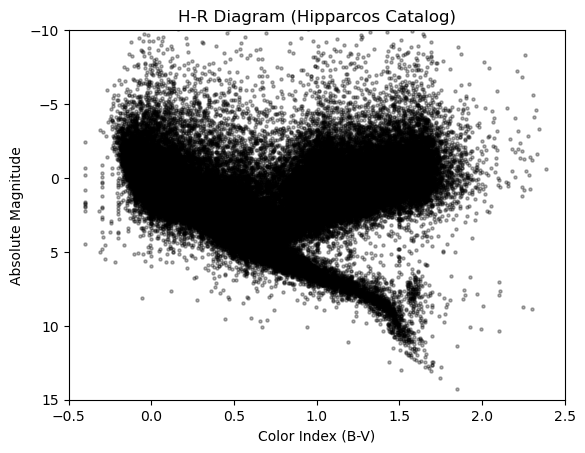

In [188]:
plt.scatter(df_clean["B-V"], Absolute_Magnitude, s = 5, alpha = 0.3, c = "k")
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel("Color Index (B-V)")
plt.ylabel("Absolute Magnitude")
plt.title("H-R Diagram (Hipparcos Catalog)")
plt.show()

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

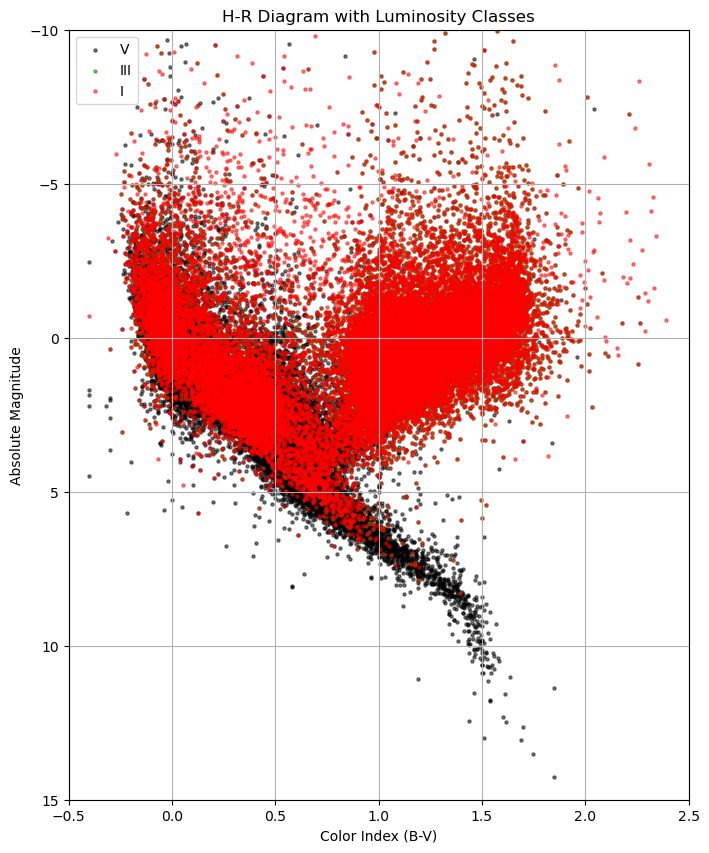

In [190]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()


With the example above, now plot the following types **WITH** and then **WITHOUT** the ones below:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

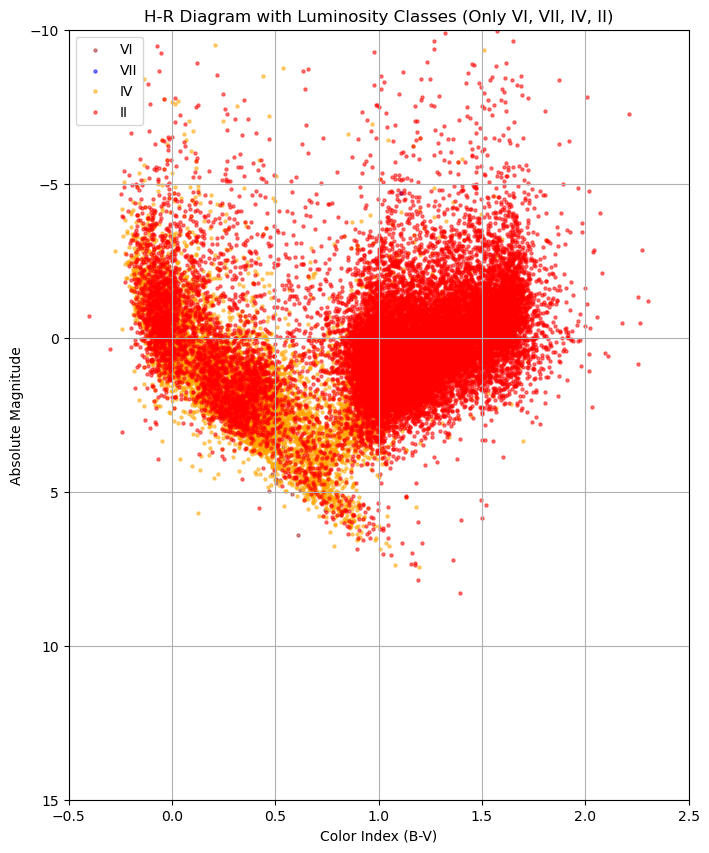

In [211]:
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes (Only VI, VII, IV, II)')

plot_luminosity_class(df_clean, "VI", "brown")  # Subdwarves
plot_luminosity_class(df_clean, "VII", "blue")  # White dwarves
plot_luminosity_class(df_clean, "IV", "orange")  # Subgiants
plot_luminosity_class(df_clean, "II", "red") # Bright giants

plt.legend()
plt.show()

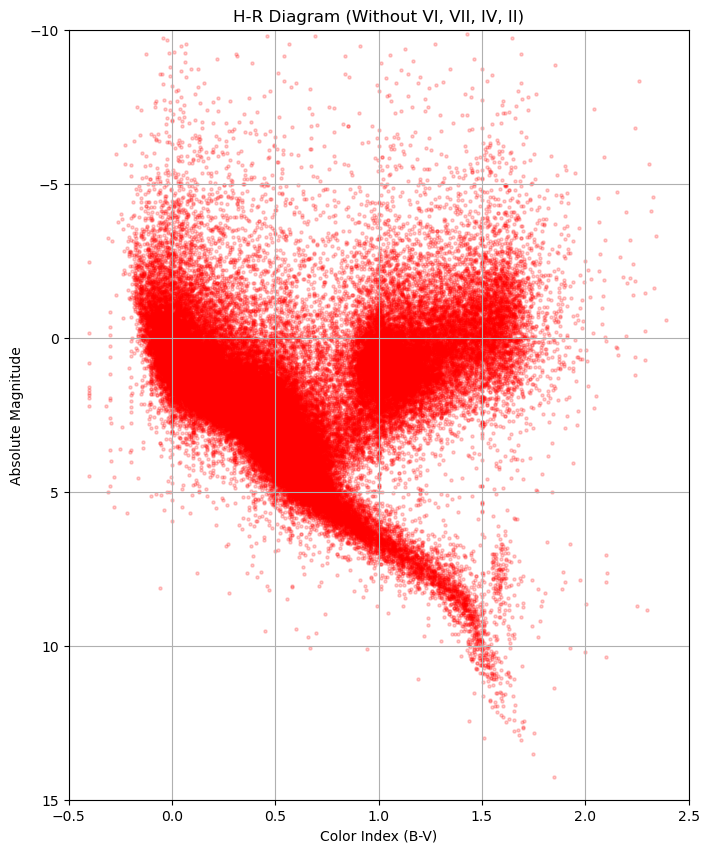

In [272]:
#Use given function to filter types we don't want
mask = df_clean["SpType"].str.contains("VI|VII|IV|II", na=False)

#The ~ makes it anti/opposite(?) so new dataframe includes all but the indicated types in the .str.contains("") above
df_filtered = df_clean[~mask]

len(df_filtered)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel("Color Index (B-V)")
plt.ylabel("Absolute Magnitude")
plt.title("H-R Diagram (Without VI, VII, IV, II)")

plt.scatter(df_filtered['B-V'], df_filtered['M_V'], s = 5, alpha = 0.2, c = "red")
plt.show()

Submit your FITS file and this notebook to Gradescope!